In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis, jet, RdYlGn_r
from netCDF4 import Dataset as NetCDFFile
import netCDF4 as nc
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf

import os

In [2]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def normalize_array(data):
    vmax = np.amax(data)
    vmin = np.min(data)
    range_data = vmax - vmin
    
    normalized_data = (data - vmin)/range_data
    
    return normalized_data

def unnormalise(data_sr, data_lr):
    max = np.max(data_lr)
    min = np.min(data_lr)
    data_sr = data_sr * (max - min) + min
    return data_sr

## Past downstream task test (PS detection)

In [311]:
file = NetCDFFile('../RDS/OCO-2/low_res/oco2_GEOS_L3CO2_day_20180901_B10206Ar.nc4')
data = np.squeeze(file.variables['XCO2'][:])
lat = np.squeeze(file.variables['lat'][:])
lon = np.squeeze(file.variables['lon'][:])

lon_reshaped = np.reshape(lon, (1, 576))
lat_reshaped = np.reshape(lat, (361, 1))

new_lon, new_lat = np.broadcast_arrays(lon_reshaped, lat_reshaped)
new_lon = new_lon.flatten()
new_lat = new_lat.flatten()

In [5]:
60-42, 14+6, 

(18, 20)

In [50]:
# Europe
# lonE = 14
# lonW = -6
# latS = 42
# latN = 60

# South America
# lonE = -42
# lonW = -62
# latS = -32
# latN = -14

# Africa
lonE = -10
lonW = 10
latS = -29
latN = -11

# Thailand
# lonE = 110
# lonW = 90
# latS = 7
# latN = 25
# print(0.5*31, 0.625*31)

extents = (lonW, lonW+19.375, latS, latS+15.5)

In [4]:
lonE_sr = find_nearest(lon, lonW+20)
lonW_sr = find_nearest(lon, lonW)
latS_sr = find_nearest(lat, latS)
latN_sr = find_nearest(lat, latS+16)

print(lonE_sr, lonW_sr, latS_sr, latN_sr)

NameError: name 'lon' is not defined

In [51]:
europe_lr = np.load('Input/sentinel/africa.npy')
europe_lr = europe_lr*1e6
# europe_lr = data[latS_sr:latN_sr, lonW_sr:lonE_sr]
# np.save('thailand.npy', np.asarray(europe_lr))

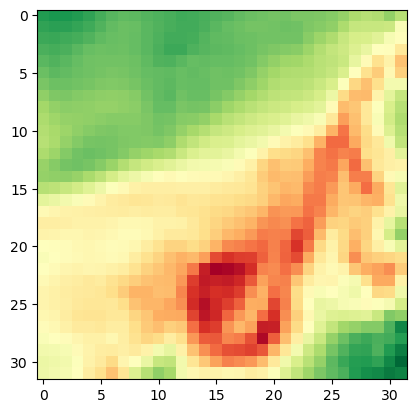

In [52]:
plt.imshow(europe_lr, cmap=RdYlGn_r)

In [53]:
europe_sr = np.load('Result/sentinel/africa.npy')
europe_sr = unnormalise(europe_sr, europe_lr)


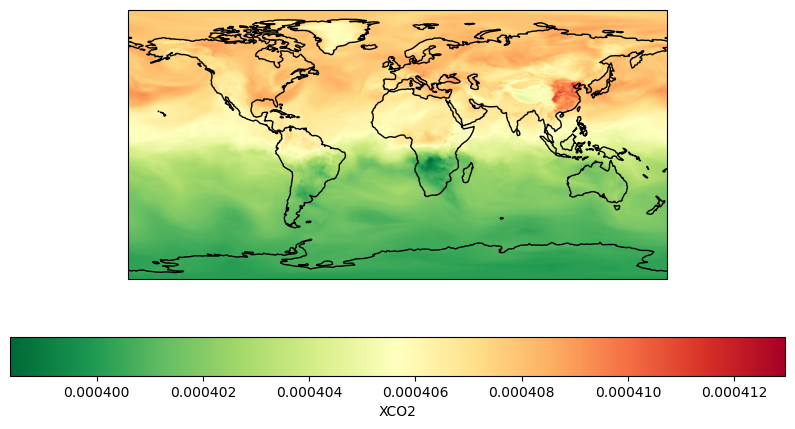

In [246]:
# Plot data
vmin = np.min(data)
vmax = np.max(data)
extent = [-180, 180, -90, 90]
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
im = ax.imshow(data, origin='lower', extent=extent, transform=ccrs.PlateCarree(), cmap=RdYlGn_r)
ax.coastlines()
plt.colorbar(im, ax=ax, orientation='horizontal', label='XCO2')


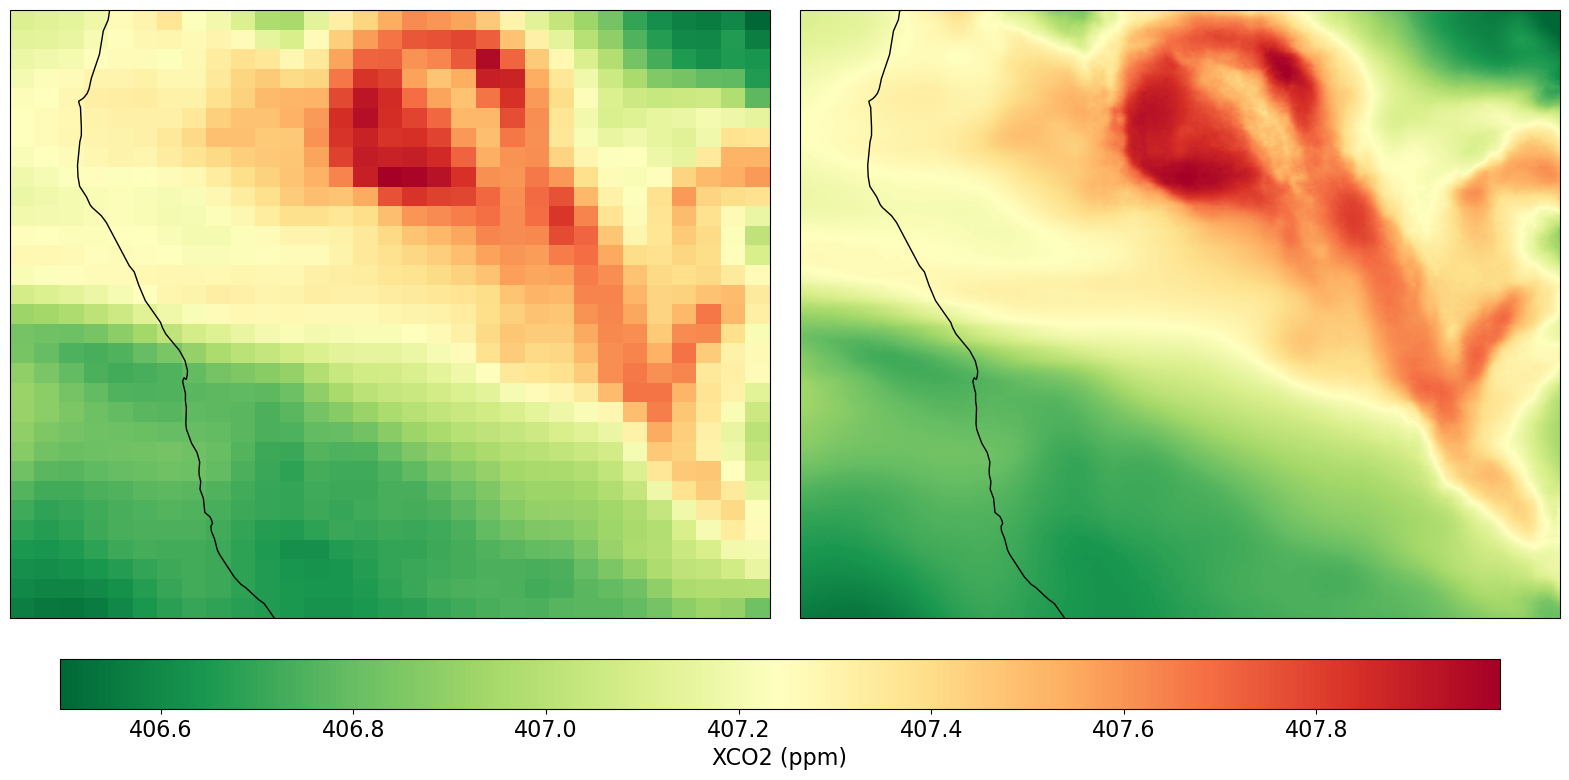

In [54]:
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
im = ax1.imshow(europe_lr[:-1,:-1], extent=extents, origin='lower', cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.coastlines()
ax2.imshow(europe_sr[:-16,:-16], extent=extents, origin='lower', cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
fig.subplots_adjust(wspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.10, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(label='XCO2 (ppm)', size=16)

In [ ]:
file_test = np.load('Input/XCO2/0_lr.npy')
file_lr = np.expand_dims(file_test, axis=0)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test)
plt.colorbar()


In [3]:
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [4]:
def unnormalize(array_sr, array_lr):
    for i in range(len(array_sr)):
        array_sr[i] = normalize(array_sr[i])
        min = np.min(array_lr[i])
        max = np.max(array_lr[i])
        array_sr[i] = (array_sr[i] * (max - min)) + min
    return array_sr

In [ ]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/sr/diff/0_lr.npy')
# file_test = np.transpose(file_test, (0, 2, 1))
file_test = unnormalize(file_test, lr)
print(np.min(file_test[0]), np.max(file_test[0]))
plt.imshow(file_test[1])
plt.colorbar()


In [ ]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/lr/diff/0_lr.npy')
# print(np.min(file_test[0]))
print(file_test.shape)
print(np.min(file_test[0]), np.max(file_test[0]))
lr = file_test
plt.imshow(file_test[1])
plt.colorbar()


In [ ]:
file_test = np.load('../../RDS/dbpn/DBPN_2/Result/XCO2/0_lr.npy')
file_test = unnormalize(np.expand_dims(file_test, axis=0), file_lr)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test[0])
plt.colorbar()

In [ ]:
file_test = np.load('Result/XCO2/0_lr_old.npy')
plt.imshow(file_test)
plt.colorbar()

In [ ]:
label_sr = np.load('../../RDS/ephemeral/difference_xco2_train/sr/labels/0_sr.npy')
plt.imshow(label_sr)

np.unique(label_sr)

In [ ]:
label_lr = np.load('../../RDS/ephemeral/difference_xco2_train/lr/labels/0_lr.npy')
plt.imshow(label_lr)

##  Bicubic interpolation

In [114]:
test = np.load('../../RDS/OCO-2/centered_arrays/ae20120522_20181031_20150103_lr.npy')
plt.imshow(test)

FileNotFoundError: [Errno 2] No such file or directory: '../../RDS/OCO-2/centered_arrays/ae20120522_20181031_20150103_lr.npy'

In [9]:
from scipy.interpolate import RegularGridInterpolator

In [94]:
europe_lr.shape

(32, 32)

In [55]:
x  = np.arange(0, 32)
y  = np.arange(0, 32)
europe_bicubic = RegularGridInterpolator((x, y), europe_lr, method='cubic')

In [56]:
# best_lat = 8
# best_lon = 10
x_sr = np.arange(0, 31, 1/16)
y_sr = np.arange(0, 31, 1/16)
xv, yv = np.meshgrid(x_sr, y_sr)
xv = xv.flatten()
yv = yv.flatten()
values = np.concatenate((xv[:, np.newaxis], yv[:, np.newaxis]), axis=1)
# values = np.array([best_lat, best_lon])
bic_europe = europe_bicubic(values)
print(bic_europe.shape)
# bic_europe = np.reshape(bic_europe, (16*15, 16*19))
# print(bic_europe)
# bic_europe = np.reshape(bic_europe, (3, 3))
# plt.imshow(bic_europe)

(246016,)


In [57]:
bic_europe = np.reshape(bic_europe, (16*31, 16*31))
bic_europe = np.transpose(bic_europe)

# plt.imshow(bic_europe)

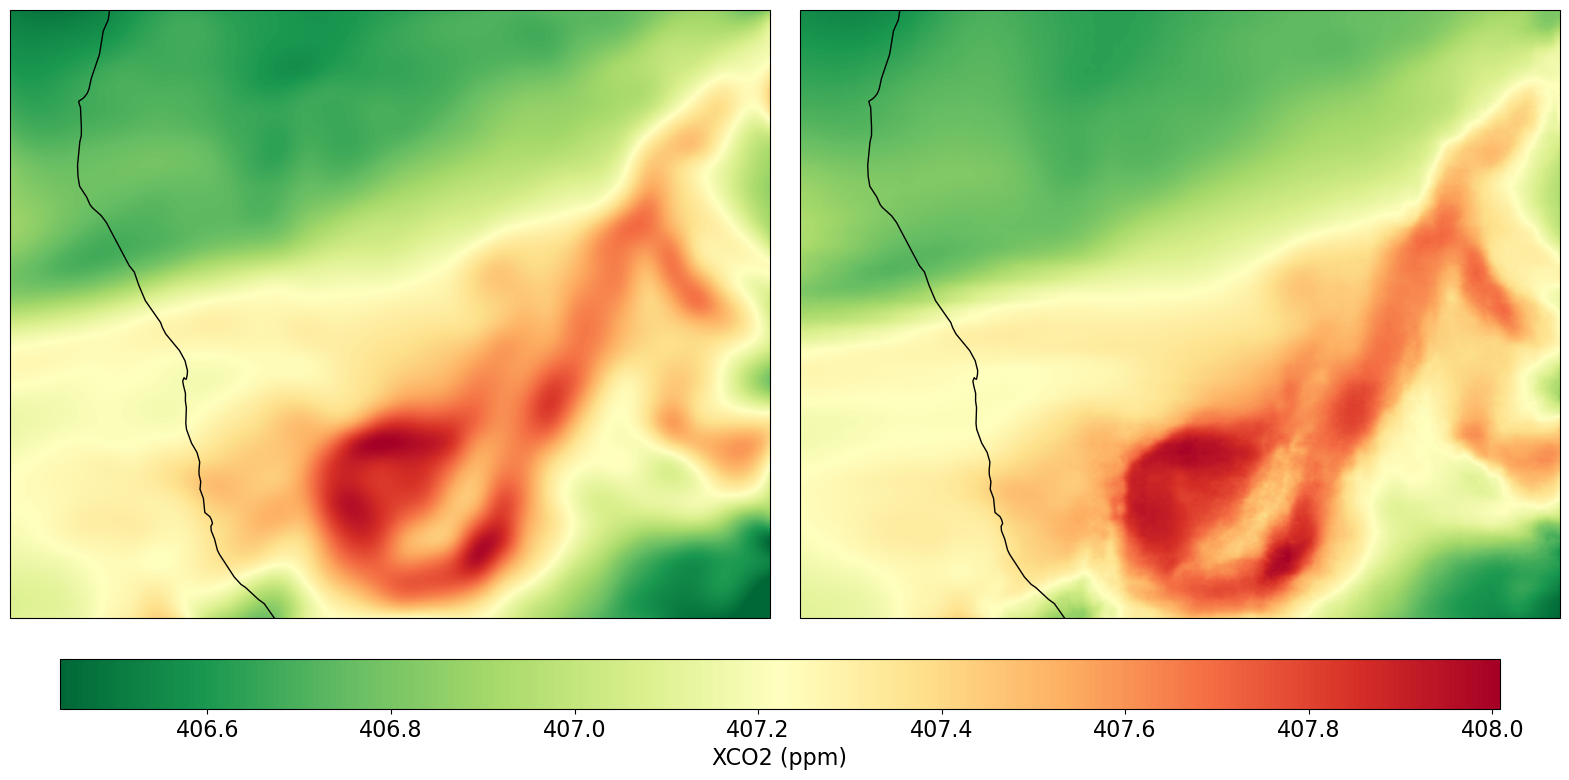

In [58]:
fig = plt.figure(figsize=(20, 10))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
plt.imshow(bic_europe,extent=extents, cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.coastlines()
im = ax2.imshow(europe_sr[:-16,:-16], extent=extents, cmap=RdYlGn_r)
# im = ax2.imshow(europe_lr[:-1,:-1], extent=extents, cmap=RdYlGn_r)
fig.subplots_adjust(wspace=0.04)
cbar_ax = fig.add_axes([0.15, 0.10, 0.72, 0.05])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(label='XCO2 (ppm)', size=16)

In [324]:
fusion_file = NetCDFFile('../RDS/data_fusion/2018/2018-09-01.nc')
xco2 = np.asarray(fusion_file.variables['XCO2'][:])
Lat = np.asarray(fusion_file.variables['Lat'][:])
Lon = np.asarray(fusion_file.variables['Lon'][:])

lonE_f = find_nearest(Lon, lonW+20)
lonW_f = find_nearest(Lon, lonW)
latS_f = find_nearest(Lat, latS)
latN_f = find_nearest(Lat, latS+16)

print(lonE_f, lonW_f, latS_f, latN_f)

552 472 232 296


In [325]:
xco2.shape
180/721, 360/1441

(0.24965325936199723, 0.2498265093684941)

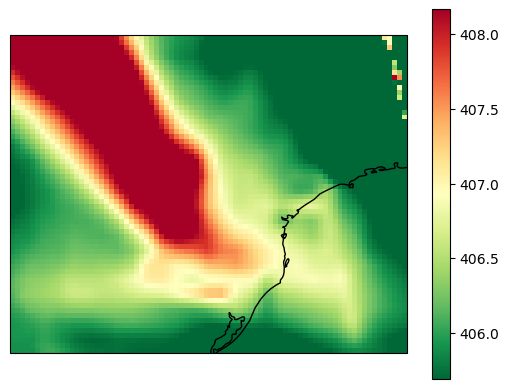

In [326]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
fus_europe = xco2[latS_f:latN_f, lonW_f:lonE_f]
plt.imshow(fus_europe, extent=extents, origin='lower', cmap=RdYlGn_r, vmin=np.min(europe_lr[:-1,:-1]), vmax=np.max(europe_lr[:-1,:-1]))
plt.colorbar()

In [60]:
minimum = np.min(europe_lr[:-1,:-1])
maximum = np.max(europe_lr[:-1,:-1])

print(minimum, maximum)

406.4952845510561 407.99055204843165


In [14]:
europe_lr.shape, bic_europe.shape, europe_sr.shape

((32, 32), (496, 496), (512, 512))

In [62]:
diff_bic_sr = bic_europe - europe_sr[:-16,:-16]

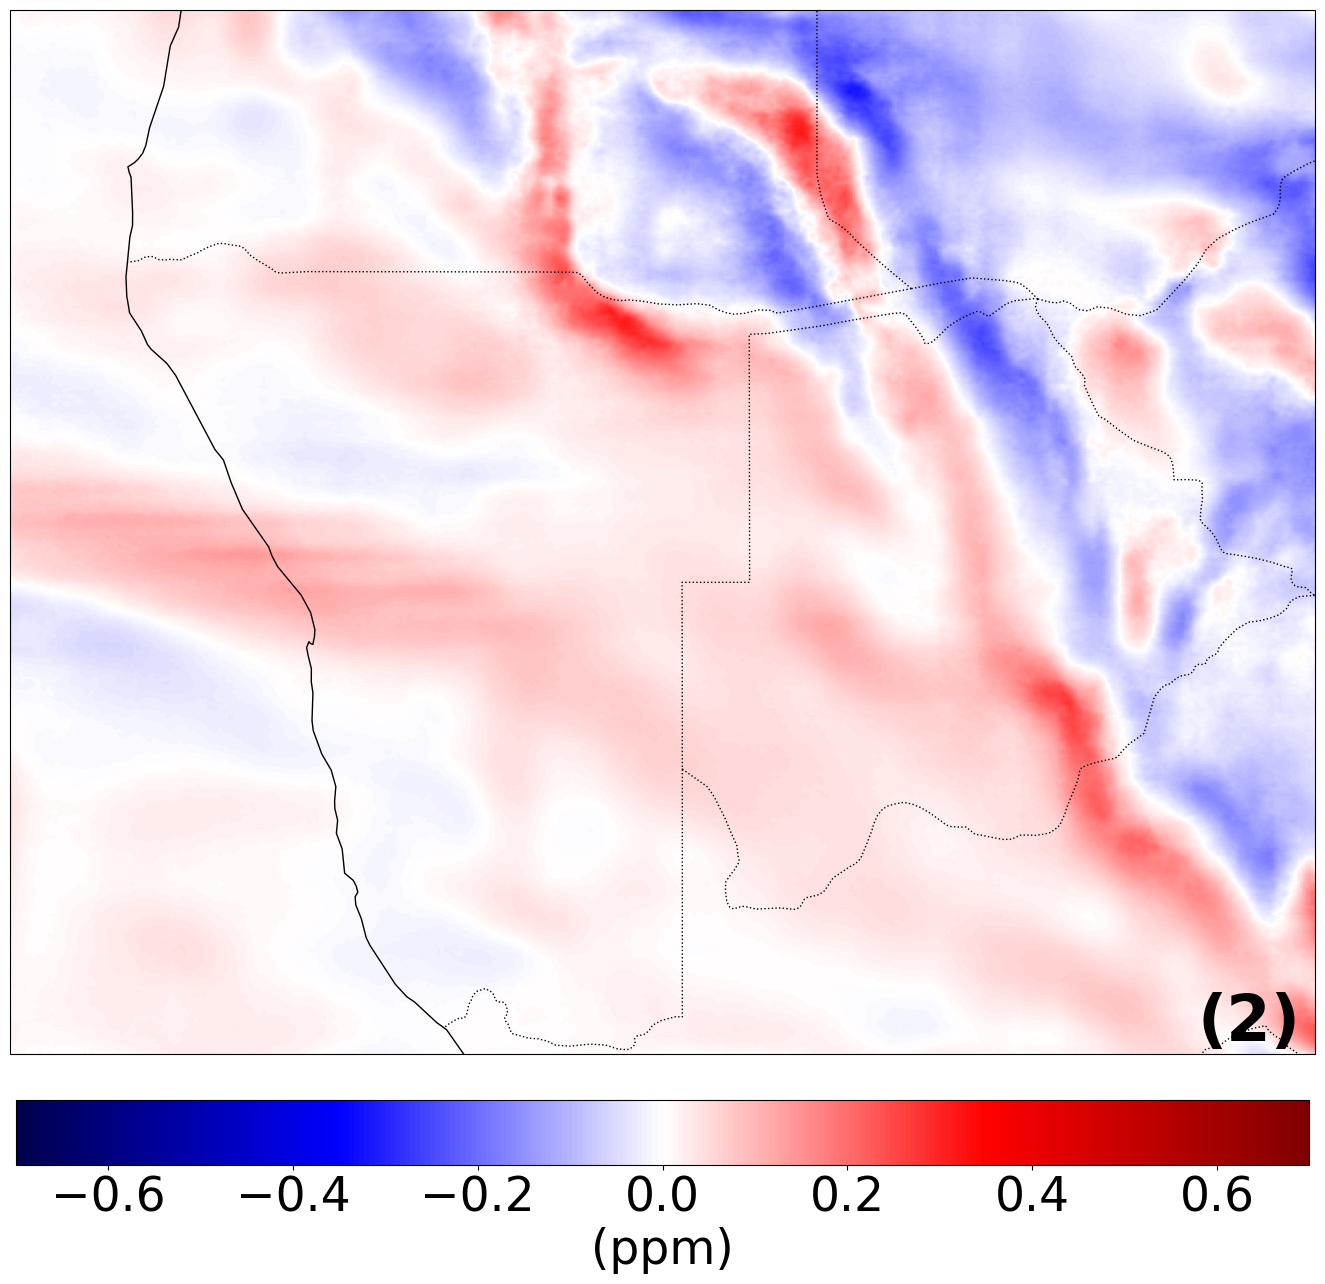

In [76]:
fig = plt.figure(figsize=(45, 15))
ax3 = fig.add_subplot(projection=ccrs.PlateCarree())
ax3.text(0.91, 0, subfigure_labels[1], transform=ax3.transAxes, fontsize=46, fontweight='bold', va='bottom', ha='left')
ax3.coastlines()
ax3.add_feature(cf.BORDERS, linestyle=':')
diff = ax3.imshow(diff_bic_sr, extent=extents, origin='lower', cmap="seismic", vmin=-0.7, vmax=0.7)
cbar = fig.colorbar(diff, ax=ax3, orientation='horizontal', fraction=0.056, pad=0.04)
cbar.ax.tick_params(labelsize=34)
cbar.set_label(label='(ppm)', size=34)

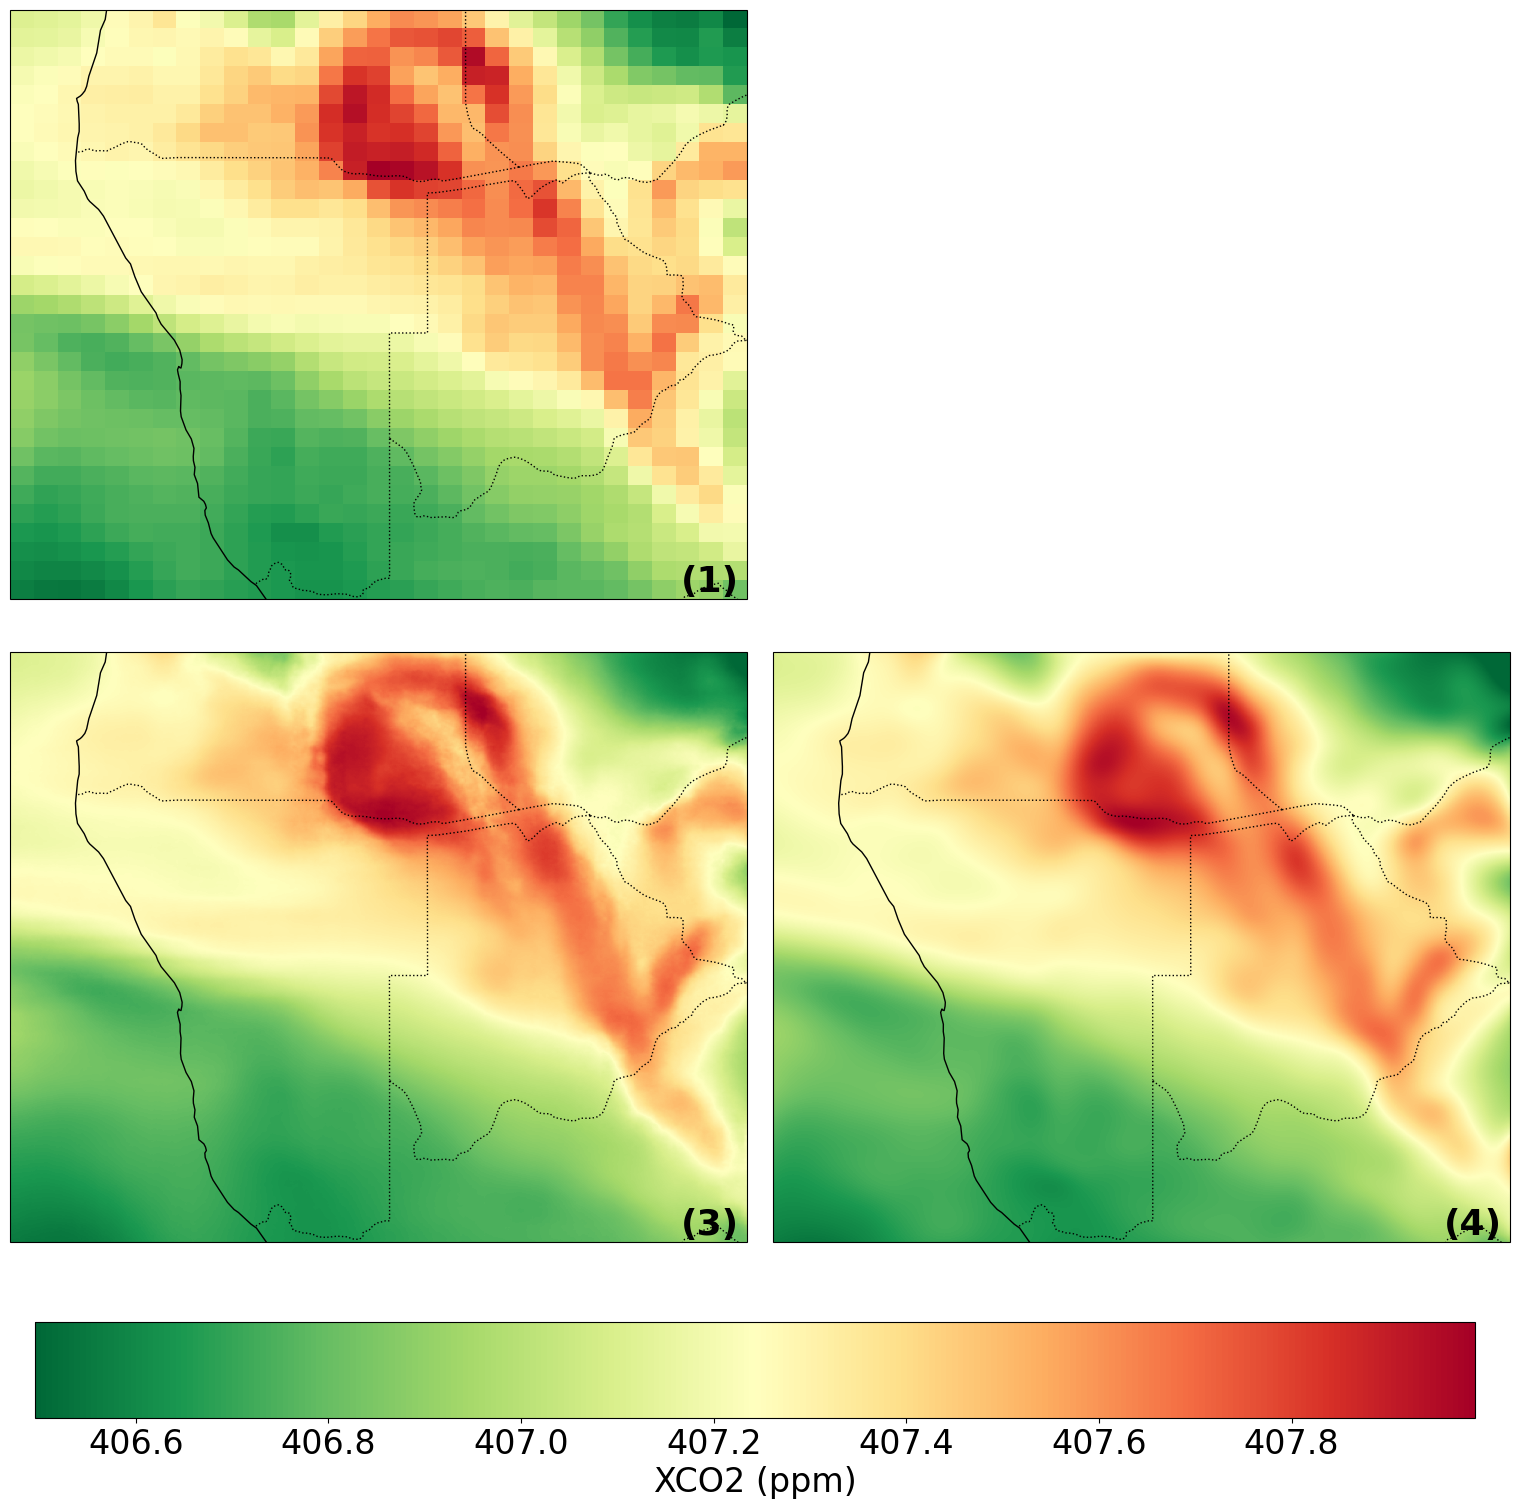

In [61]:
# sns.set()
subfigure_labels = ['(1)', '(2)', '(3)', '(4)']
fig = plt.figure(figsize=(20, 16))
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1.text(0.91, 0, subfigure_labels[0], transform=ax1.transAxes, fontsize=26, fontweight='bold', va='bottom', ha='left')
ax1.coastlines()
ax1.add_feature(cf.BORDERS, linestyle=':')
im = ax1.imshow(europe_lr[:-1,:-1], extent=extents, origin='lower', cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
ax2.text(0.91, 0, subfigure_labels[2], transform=ax2.transAxes, fontsize=26, fontweight='bold', va='bottom', ha='left')
ax2.coastlines()
ax2.add_feature(cf.BORDERS, linestyle=':')
ax2.imshow(europe_sr[:-16,:-16], extent=extents, origin='lower', cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
# ax3 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
# ax3.text(0.91, 0, subfigure_labels[2], transform=ax3.transAxes, fontsize=26, fontweight='bold', va='bottom', ha='left')
# ax3.coastlines()
# ax3.add_feature(cf.BORDERS, linestyle=':')
# diff = ax3.imshow(diff_bic_sr, extent=extents, origin='lower', cmap="seismic", vmin=-0.7, vmax=0.7)
# fig.colorbar(diff, ax=ax3, orientation='horizontal', label='(ppm)')
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
ax4.text(0.91, 0, subfigure_labels[3], transform=ax4.transAxes, fontsize=26, fontweight='bold', va='bottom', ha='left')
ax4.coastlines()
ax4.add_feature(cf.BORDERS, linestyle=':')
ax4.imshow(bic_europe, extent=extents, origin='lower', cmap=RdYlGn_r, vmin=minimum, vmax=maximum)
# fig.subplots_adjust(wspace=0, hspace=0.0)
fig.subplots_adjust(wspace=-0.03, hspace=0.09)
cbar_ax = fig.add_axes([0.15, 0.0, 0.72, 0.06])
cbar = fig.colorbar(im, orientation='horizontal', cax=cbar_ax)
# cbar_ax = fig.add_axes([0.95, 0.12, 0.05, 0.75])
# cbar = fig.colorbar(im, orientation='vertical', cax=cbar_ax)
cbar.ax.tick_params(labelsize=24)
cbar.set_label(label='XCO2 (ppm)', size=24)

## Land Surface Temperature data distribution VS CO2 data distribution

In [3]:
def normalize_array(data):
    vmax = np.amax(data)
    vmin = np.min(data)
    range_data = vmax - vmin
    
    normalized_data = (data - vmin)/range_data
    
    return normalized_data

def random_window(array, size=32):
    # print(array.shape)
    x = np.random.randint(0, array.shape[0]-size)
    y = np.random.randint(0, array.shape[1]-size)
    
    return array[x:x+size, y:y+size]

north_america_box = -135,10,-65.0,60
europe_box = -10, 40, 35, 70
africa_box = -20, -35, 50, 40
asia_box = 40, 0, 150, 70
south_america_box = -80, -50, -40, 10
oceania_box = 115, -40, 155, -10

def sample_within_coordinates(array, coordinates, lon, lat):
    lonW, latS, lonE, latN = coordinates
    lonW = find_nearest(lon, lonW)
    lonE = find_nearest(lon, lonE)
    latS = find_nearest(lat, latS)
    latN = find_nearest(lat, latN)

    if latS > latN:
        return random_window(array[latN:latS, lonW:lonE])
    else:
        return random_window(array[latS:latN, lonW:lonE])

def bin_values(array, bins=11):
    binned_array = np.digitize(array, np.linspace(0, 1, bins))
    
    return binned_array

In [ ]:
file = xr.open_dataset('../Point_source_detection/data/OCO-2/oco2_GEOS_L3CO2_day_20150101_B10206Ar.nc4')
xco2 = file['XCO2'][0,:,:]
lon = file['lon']
lat = file['lat']


fig, axs = plt.subplots(3, 2, figsize=(15, 15))

regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

for ax, (region_name, region_box) in zip(axs.flatten(), regions.items()):
    region_win = sample_within_coordinates(xco2, region_box, lon, lat)
    norm_region_win = normalize_array(region_win)
    sns.kdeplot(np.asarray(norm_region_win).flatten(), ax=ax, fill=True)
    ax.set_title(f'{region_name} Bin Distribution')

plt.tight_layout()
plt.show()

In [ ]:
import json

# file = xr.open_dataset('../Point_source_detection/data/OCO-2/oco2_GEOS_L3CO2_day_20150101_B10206Ar.nc4')
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

region_bins = {region: [] for region in regions}

for filename in os.listdir('../Point_source_detection/data/OCO-2/'):
    file = xr.open_dataset('../Point_source_detection/data/OCO-2/'+filename)
    xco2 = file['XCO2'][0,:,:]
    lon = file['lon']
    lat = file['lat']

    for region_name, region_box in regions.items():
        region_win = sample_within_coordinates(xco2, region_box, lon, lat)
        norm_region_win = normalize_array(region_win)
        
        bins_region = bin_values(norm_region_win)
        region_card = np.bincount(bins_region.flatten())
        region_bins[region_name].append(region_card)

for ax, (region_name, bins_list) in zip(axs.flatten(), region_bins.items()):
    ax.boxplot(np.asarray(bins_list), patch_artist=True)
    ax.set_ylim(0, 250)
    ax.set_title(f'{region_name} Bin Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import json

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

with open('region_bins.json', 'r') as f:
    region_bins = json.load(f)

for ax, (region_name, bins_list) in zip(axs.flatten(), region_bins.items()):
    bins = np.asarray(bins_list)[:, 1:11]
    ax.boxplot(bins, patch_artist=True)
    ax.set_ylim(0, 250)
    ax.set_xticks(np.arange(1, bins.shape[1] + 1))
    ax.set_xticklabels([f'{i/10}' for i in range(1, bins.shape[1] + 1)])
    ax.set_title(f'{region_name} Bin Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import json
import seaborn as sns

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

with open('region_dist.json', 'r') as f:
    region_dist = json.load(f)

for ax, (region_name, dist) in zip(axs.flatten(), region_dist.items()):
    sns.kdeplot(np.asarray(dist).flatten(), ax=ax, fill=True, legend=False)
    sns.kdeplot(data=div2k_dist, x='value', weights='occurence', ax = ax, fill=True, legend=False)
    sns.kdeplot(data=modis_dist, x='value', weights='occurence', ax = ax, fill=True, legend=False)
    sns.kdeplot(data=dota_dist, x='value', weights='occurence', ax = ax, fill=True, legend=False)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_title(f'{region_name} Distribution', family='sans-serif', fontsize=21)
fig.legend(['Normalized XCO2 distribution per region', 'DIV2K Images Distribution', 'Normalized LST distribution', 'DOTA Images Distribution'], loc='lower left', ncol=2, fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
def gridify_than_normalize(data):
    norm_arrays = []
    # data = np.asarray(data)
    for i in range(0, data.shape[0], 32):
        for j in range(0, data.shape[1], 32):
            sub_array = data[i:i+32, j:j+32]
            if sub_array[~sub_array.mask].size > 0:
                norm_sub_array = normalize_array(sub_array[~sub_array.mask])
                bin_samples = bin_values(norm_sub_array)
                bin_count = np.bincount(bin_samples)
                if len(bin_count) == 12:
                    norm_arrays.append(norm_sub_array)
    return norm_arrays

In [ ]:
file = nc.Dataset('../RDS/earthdata/MOD11C1_061-20241106_171429/MOD11C1.A2017032.061.2022024134133.hdf', 'r')
# file = nc.Dataset('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/'+files[j], 'r')
temp_data = file['LST_Day_CMG'][:]
normed_data = gridify_than_normalize(temp_data)
modis_dist = np.concatenate((modis_dist, np.asarray(normed_data).flatten()), axis=None)

In [33]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def random_window(array, size=32):
    # print(array.shape)
    x = np.random.randint(0, array.shape[0]-size)
    y = np.random.randint(0, array.shape[1]-size)
    
    return array[x:x+size, y:y+size]

def normalize_array(data):
    vmax = np.amax(data)
    vmin = np.min(data)
    range_data = vmax - vmin
    
    normalized_data = (data - vmin)/range_data
    
    return normalized_data

north_america_box = -135,10,-65.0,60
europe_box = -10, 40, 35, 70
africa_box = -20, -35, 50, 40
asia_box = 40, 0, 150, 70
south_america_box = -80, -50, -40, 10
oceania_box = 115, -40, 155, -10

def sample_within_coordinates(array, coordinates, lon, lat):
    lonW, latS, lonE, latN = coordinates
    lonW = find_nearest(lon, lonW)
    lonE = find_nearest(lon, lonE)
    latS = find_nearest(lat, latS)
    latN = find_nearest(lat, latN)

    if latS > latN:
        return random_window(array[latN:latS, lonW:lonE])
    else:
        return random_window(array[latS:latN, lonW:lonE])

def bin_values(array, bins=11):
    binned_array = np.digitize(array, np.linspace(0, 1, bins))
    
    return binned_array

def gridify_than_normalize(data):
    norm_arrays = []
    # data = np.asarray(data)
    for i in range(0, data.shape[0], 32):
        for j in range(0, data.shape[1], 32):
            sub_array = data[i:i+32, j:j+32]
            if sub_array[~sub_array.mask].size > 0:
                norm_sub_array = normalize_array(sub_array[~sub_array.mask])
                bin_samples = bin_values(norm_sub_array)
                bin_count = np.bincount(bin_samples)
                if len(bin_count) == 12:
                    norm_arrays.append(norm_sub_array)
    return norm_arrays

In [34]:
# modis_dist = []
files = os.listdir('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/')
for i in range(4):
    file = nc.Dataset('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/'+files[i], 'r')
    temp_data = file['LST_Day_CMG'][:]
    normed_data = gridify_than_normalize(temp_data)
    flattened_data = np.concatenate([arr.flatten() for arr in normed_data])
    modis_dist.append(flattened_data)


In [ ]:
flat_list = [
    x
    for xs in modis_dist
    for x in xs
]
len(flat_list)

In [ ]:
latitudes = np.linspace(90, -90, nrows)
longitudes = np.linspace(-180, 180, ncols)
# Sample random 32*32 window between lat [-70, 70] and lon [-180, 180] and only consider values where mask is false
# sample = sample_within_coordinates(temp_data, [-180, -70, 180, 70], longitudes, latitudes)

# Normalize window
norm_sample = normalize_array(sample[~sample.mask])
# Bin values
bin_sample = bin_values(norm_sample[~norm_sample.mask])
np.bincount(bin_sample)
# Plot histogram

In [ ]:
everything = np.load('modis_bins.npy')

plt.figure(figsize=(10, 5))
plt.boxplot(everything, patch_artist=True)
# plt.set_ylim(0, 250)
# plt.set_title('Bin Distribution')
plt.xticks(ticks=np.arange(1, everything.shape[1] + 1), labels=[f'{i/10}' for i in range(1, everything.shape[1] + 1)])
plt.legend()

In [5]:
def bin_values(array, bins=100):
    binned_array = np.digitize(array, np.linspace(0, 1, bins))
    
    return binned_array

def gridify_than_normalize(data):
    norm_arrays = [0 for i in range(100)]
    # data = np.asarray(data)
    for i in range(0, data.shape[0], 32):
        for j in range(0, data.shape[1], 32):
            sub_array = data[i:i+32, j:j+32]
            try:
                normed_sub_array = normalize_array(sub_array)
                bin_samples = bin_values(normed_sub_array).flatten()
                bin_count = np.bincount(bin_samples)
                norm_arrays = [x + y for x, y in zip(norm_arrays, bin_count)]
            except:
                print("Error dividing by zero")
    return norm_arrays

In [21]:
dist = [0 for i in range(101)]
files = os.listdir('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/')
for i in range(4):
    file = nc.Dataset('/scratch_hive/ar1619/RDS/earthdata/MOD11C1_061-20241106_171429/'+files[i], 'r')
    temp_data = file['LST_Day_CMG'][:]
    normed_data = gridify_than_normalize(temp_data)
    dist = [x + y for x, y in zip(dist, normed_data)]



In [39]:
np.save('modis_dist.npy', np.asarray(dist))

In [ ]:
mod_df = pd.DataFrame(data=np.asarray([x, dist]).transpose(), columns=['value', 'occurence'])
sns.kdeplot(data=mod_df, x='value', weights='occurence', fill=True)

In [ ]:
import seaborn as sns
sns.kdeplot(np.asarray(dist).flatten(), fill=True)
plt.xlabel('Index')
plt.ylabel('Occurrence')
plt.title('KDE Plot of Distribution')
plt.show()

## DIV2K data distribution

In [4]:
div2k_dist = np.load('div2k_dist.npy')
x = np.linspace(0, 1, 100)

div2k_dist = pd.DataFrame(np.asarray([x, div2k_dist]).transpose(), columns=['value', 'occurence'])

In [5]:
modis_dist = np.load('modis_dist.npy')

modis_dist = pd.DataFrame(np.asarray([x, modis_dist]).transpose(), columns=['value', 'occurence'])

In [6]:
dota_dist = np.load('dota_dist.npy')
dota_dist = pd.DataFrame(np.asarray([x, dota_dist]).transpose(), columns=['value', 'occurence'])

In [41]:
# oco2_dist = np.load('oco2_dist.npy')
oco2_dist = pd.DataFrame(np.asarray([x, oco2_region_dist]).transpose(), columns=['value', 'occurence'])

In [ ]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 10))
sns.kdeplot(data=oco2_dist, x='value', weights='occurence', fill=True, ax=ax)
sns.kdeplot(data=div2k_dist, x='value', weights='occurence', fill=True, ax=ax)
sns.kdeplot(data=modis_dist, x='value', weights='occurence', fill=True, ax=ax)
sns.kdeplot(data=dota_dist, x='value', weights='occurence', fill=True, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=16)
fig.legend(['Normalized XCO2 distribution', 'DIV2K Images Distribution', 'Normalized LST distribution', 'DOTA Images Distribution'], loc='upper right', ncol=1, fontsize=18, bbox_to_anchor=(1, 0.89))

In [ ]:
tips = sns.load_dataset("tips")
tips.head()

In [ ]:
import skimage as ski
from skimage.color import rgb2gray
import seaborn as sns

x = np.linspace(0, 1, 100)
dist = [0 for i in range(101)]
files = os.listdir('../RDS/DOTA/')
for i in range(3):
    file = ski.io.imread('../RDS/DOTA/'+files[i])
    file_gray = np.asarray(rgb2gray(file))
    normed_data = gridify_than_normalize(file_gray)
    dist = [x + y for x, y in zip(dist, normed_data)]

dist_pd = pd.DataFrame(np.asarray([x, dist]).transpose(), columns=['value', 'occurence'])
sns.kdeplot(data=dist_pd, x='value', weights='occurence', fill=True)

In [18]:
import json 
regions = {
    'Europe': europe_box,
    'North America': north_america_box,
    'South America': south_america_box,
    'Oceania': oceania_box,
    'Africa': africa_box,
    'Asia': asia_box
}

with open('region_dist.json', 'r') as f:
    region_dist = json.load(f)

In [39]:
oco2_region_dist = [0 for i in range(100)]
for (region_name, dist) in region_dist.items():
    # bin dist into 101 bins
    binned_dist = np.digitize(dist, np.linspace(0, 1, 100))
    region_card = np.bincount(binned_dist.flatten())
    oco2_region_dist = [x + y for x, y in zip(oco2_region_dist, region_card)]

In [ ]:
len(oco2_region_dist)